### EDA

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [163]:
df = pd.read_csv('data/train.csv', index_col='PassengerId')
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [164]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

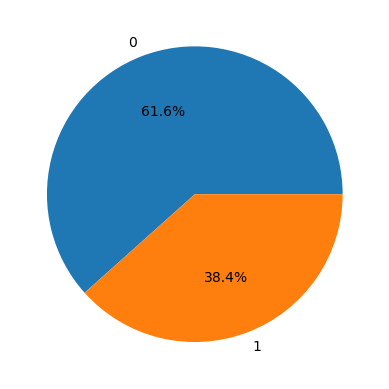

In [165]:
df.Survived.value_counts().plot.pie(autopct='%1.1f%%')

#### Фича Sex

Female выживает больше, чем male. Пока что просто сделать фичу is_female со значениями 0 или 1

In [166]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [167]:
df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex'>

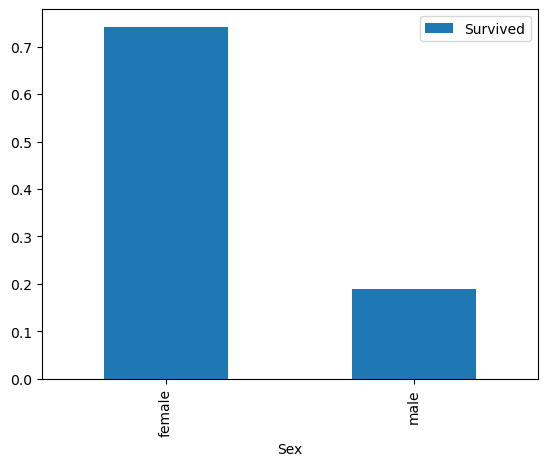

In [168]:
df[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar()

In [169]:
df.replace({"Sex": {"male": 0, "female": 1}}, inplace=True)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,S


#### Фича Pclass

In [170]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

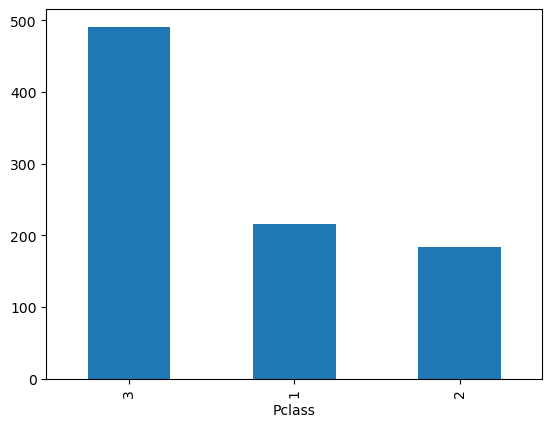

In [171]:
df['Pclass'].value_counts().plot.bar()

In [172]:
pd.crosstab(df.Pclass, df.Survived, margins=True)

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


In [173]:
df.loc[:, ['Pclass', 'Sex', 'Survived']].corr()

,Pclass,Sex,Survived
Pclass,1.000000,-0.131900,-0.338481
Sex,-0.131900,1.000000,0.543351
Survived,-0.338481,0.543351,1.000000


#### SibSp и Parch

In [174]:
cat_cols = ['SibSp', 'Embarked', 'Parch']
[print(df[x].value_counts(), '\n') for x in cat_cols]

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64 

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64 

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64 



[None, None, None]

#### Cabin

In [175]:
# TODO extract letter from cabin
df.Cabin.value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

#### Age и Fare

In [176]:
numeric_cols = ['Age', 'Fare']
df[numeric_cols]

,Age,Fare
PassengerId,,
1,22.0,7.2500
2,38.0,71.2833
3,26.0,7.9250
4,35.0,53.1000
5,35.0,8.0500
...,...,...
887,27.0,13.0000
888,19.0,30.0000
889,NaN,23.4500


#### Age

In [177]:
print(f'{df.Age.max()=}, {df.Age.min()=}, {df.Age.mean()=}')

df.Age.max()=np.float64(80.0), df.Age.min()=np.float64(0.42), df.Age.mean()=np.float64(29.69911764705882)


Age from Name

In [178]:
df["Initial"] = df["Name"].str.extract("([A-Za-z]+)\\.")

df['Initial'].value_counts()

Initial
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [179]:
# TODO extract is_military?
df.replace(
    {
        "Initial": {
            "Mlle": "Miss",
            "Mme": "Miss",
            "Ms": "Miss",
            "Dr": "Mr",
            "Major": "Mr",
            "Lady": "Mrs",
            "Countess": "Mrs",
            # "Jonkheer": "Other",
            # "Col": "Other",
            # "Rev": "Other",
            "Capt": "Mr",
            "Sir": "Mr",
            "Don": "Mr",
        }
    },
    inplace=True,
)

df.loc[~df["Initial"].isin(["Mr", "Miss", "Mrs"]), "Initial"] = "Other"

df["Initial"].value_counts()

Initial
Mr       529
Miss     186
Mrs      127
Other     49
Name: count, dtype: int64

In [180]:
mean_ages_by_initials = df.groupby('Initial').Age.mean().round()
mean_ages_by_initials

Initial
Miss     22.0
Mr       33.0
Mrs      36.0
Other    13.0
Name: Age, dtype: float64

In [181]:
for initial in list(mean_ages_by_initials.keys()):
    df.loc[
        (df.Age.isnull()) & (df.Initial == initial),
        'Age'
    ] = mean_ages_by_initials[initial]

df.Age.isnull().any()

np.False_

#### Embarked

N/A заменить модой

In [182]:
df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [183]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
Initial       0
dtype: int64

In [184]:
embarked_mode = df.Embarked.mode()[0]
print(embarked_mode)
df.fillna({'Embarked': embarked_mode}, inplace=True)
df.Embarked.isnull().sum()

S


np.int64(0)

In [185]:
df.loc[:, ~df.columns.isin(cat_cols)]

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Initial
PassengerId,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,A/5 21171,7.2500,NaN,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,PC 17599,71.2833,C85,Mrs
3,1,3,"Heikkinen, Miss. Laina",1,26.0,STON/O2. 3101282,7.9250,NaN,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,113803,53.1000,C123,Mrs
5,0,3,"Allen, Mr. William Henry",0,35.0,373450,8.0500,NaN,Mr
...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",0,27.0,211536,13.0000,NaN,Other
888,1,1,"Graham, Miss. Margaret Edith",1,19.0,112053,30.0000,B42,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,22.0,W./C. 6607,23.4500,NaN,Miss


In [187]:
bins_data = pd.cut(df['Age'], bins=5, labels=range(0, 5), retbins=True)
bins = bins_data[1]
print(bins)

df.iloc[0].Age

df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=range(0, 5))
df.Age_group.isna().sum()

len(df.loc[df.Age_group.isna()])

[ 0.34042 16.336   32.252   48.168   64.084   80.     ]


0

In [188]:
df['Family_Size'] = df['Parch'] + df['SibSp']
df['Alone'] = 0
df.loc[df.Family_Size == 0, 'Alone'] = 1

df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_group,Family_Size,Alone
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,1,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,1,0
3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,0,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,Mrs,2,1,0
5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,Mr,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,Other,1,0,1
888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S,Miss,1,0,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,22.0,1,2,W./C. 6607,23.4500,NaN,S,Miss,1,3,0


In [189]:
df['Fare_Range'] = pd.qcut(df['Fare'], 4, labels=range(0, 4))
df.Fare_Range.value_counts()

Fare_Range
1    224
0    223
2    222
3    222
Name: count, dtype: int64

In [190]:
df = df.drop(columns=["Name", "Ticket", "Cabin", "Initial", "Embarked", "Age", "Fare"])
df

,Survived,Pclass,Sex,SibSp,Parch,Age_group,Family_Size,Alone,Fare_Range
PassengerId,,,,,,,,,
1,0,3,0,1,0,1,1,0,0
2,1,1,1,1,0,2,1,0,3
3,1,3,1,0,0,1,0,1,1
4,1,1,1,1,0,2,1,0,3
5,0,3,0,0,0,2,0,1,1
...,...,...,...,...,...,...,...,...,...
887,0,2,0,0,0,1,0,1,1
888,1,1,1,0,0,1,0,1,2
889,0,3,1,1,2,1,3,0,2


Корреляция с таргетом - мб дропнуть SibSp, Parch, Family_Size

In [200]:
df.corr(numeric_only=True)

,Survived,Pclass,SibSp,Parch,Family_Size,Alone
Survived,1.000000,-0.338481,-0.035322,0.081629,0.016639,-0.203367
Pclass,-0.338481,1.000000,0.083081,0.018443,0.065997,0.135207
SibSp,-0.035322,0.083081,1.000000,0.414838,0.890712,-0.584471
Parch,0.081629,0.018443,0.414838,1.000000,0.783111,-0.583398
Family_Size,0.016639,0.065997,0.890712,0.783111,1.000000,-0.690922
Alone,-0.203367,0.135207,-0.584471,-0.583398,-0.690922,1.000000


#### PCA

In [199]:
from sklearn.decomposition import PCA

X = df.drop(columns=['Survived'])
y = df[['Survived']]

pca = PCA()
X_pca = pca.fit(X)
print(X_pca.explained_variance_ratio_, '\n')

loadings_df = pd.DataFrame(
    X_pca.components_,
    columns=X.columns, # Your original dataframe column names
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

print(loadings_df.loc['PC1'].abs().sort_values(ascending=False))

# Find the column with the maximum absolute value in each component
most_important_cols = [
    loadings_df.columns[np.abs(component).argmax()] 
    for component in pca.components_
]
most_important_cols

[5.94185308e-01 1.99087412e-01 7.80776472e-02 6.50031892e-02
 2.64191372e-02 2.45455197e-02 1.26817867e-02 1.09617758e-16] 

Family_Size    0.748723
SibSp          0.462939
Fare_Range     0.312957
Parch          0.285784
Alone          0.171030
Age_group      0.113992
Sex            0.054103
Pclass         0.017729
Name: PC1, dtype: float64


['Family_Size',
 'Fare_Range',
 'Age_group',
 'Parch',
 'Sex',
 'Pclass',
 'Alone',
 'Parch']

#### Feature Engineering